# California Housing Price Prediction — End-to-End ML Pipeline

**CodeAlpha Machine Learning Internship — Project Notebook**

This notebook documents a complete supervised learning workflow: exploratory data analysis, statistical outlier detection and handling, model training, and feature importance analysis.

**Dataset:** California Housing (1990 U.S. Census, Pace & Barry 1997) — 20,640 samples, 9 features + target.
**Task:** Predict median house value for a census block group.
**Author:** Muhammad Aamir

---

### Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis](#2)
3. [Outlier Detection & Handling](#3)
4. [Feature Engineering & Preprocessing](#4)
5. [Model Training — Supervised Learning](#5)
6. [Feature Importance Analysis](#6)
7. [Before/After Outlier Handling — Impact Summary](#7)
8. [Conclusions](#8)


<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

**About this dataset.** The California Housing dataset is derived from the 1990 U.S. Census. Each row represents one census block group (the smallest geographic unit the Census Bureau publishes data for), with features describing the housing and demographics of that area, and a target of `median_house_value` in USD.

I'm using this dataset rather than a synthetic one because it's a real, independently verifiable public dataset with genuine data-quality issues (missing values, value capping, skewed distributions) — which makes for an honest outlier-detection exercise rather than a manufactured one.

In [2]:
df = pd.read_csv("../data/housing.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 20,640 rows x 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


<a id='2'></a>
## 2. Exploratory Data Analysis

### 2.1 Missing values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary

,missing_count,missing_pct
total_bedrooms,207,1.0


`total_bedrooms` has 207 missing values (about 1% of rows) — a small, plausible amount consistent with real-world census reporting gaps. I'll address this with median imputation in the preprocessing pipeline (Section 4), since median is robust to the skew we'll see below.

### 2.2 Target variable distribution

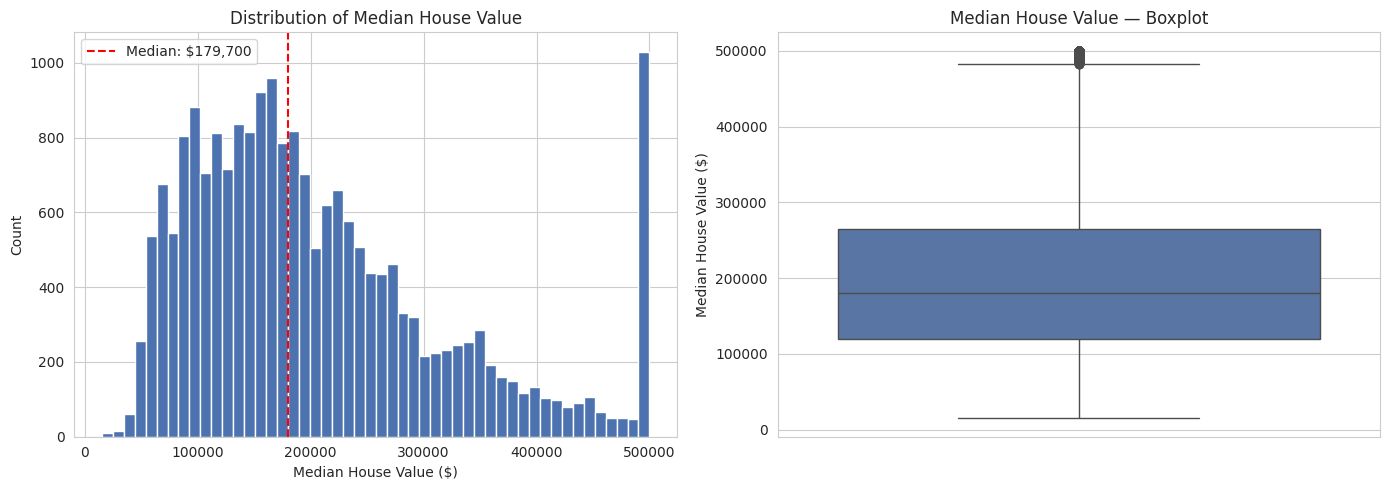

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["median_house_value"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["median_house_value"].median(), color="red", linestyle="--", label=f'Median: ${df["median_house_value"].median():,.0f}')
axes[0].set_title("Distribution of Median House Value")
axes[0].set_xlabel("Median House Value ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

sns.boxplot(y=df["median_house_value"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Median House Value — Boxplot")
axes[1].set_ylabel("Median House Value ($)")

plt.tight_layout()
plt.savefig("../images/target_distribution.png", bbox_inches="tight")
plt.show()

In [7]:
capped = (df["median_house_value"] == 500001).sum()
print(f"Rows with median_house_value == $500,001 (top-coded cap): {capped} ({capped/len(df)*100:.2f}%)")

Rows with median_house_value == $500,001 (top-coded cap): 965 (4.68%)


**Observation:** There's a visible spike at exactly \$500,001 — this is a **top-coding artifact**, not a genuine market value. The Census Bureau capped reported values at this ceiling during collection. These aren't statistical outliers in the traditional sense; they're a known data limitation, and I remove them explicitly before modeling (Section 3) rather than lumping them in with IQR-based outlier detection, since IQR would only catch a small fraction of them and mask the real cause.

### 2.3 Feature distributions

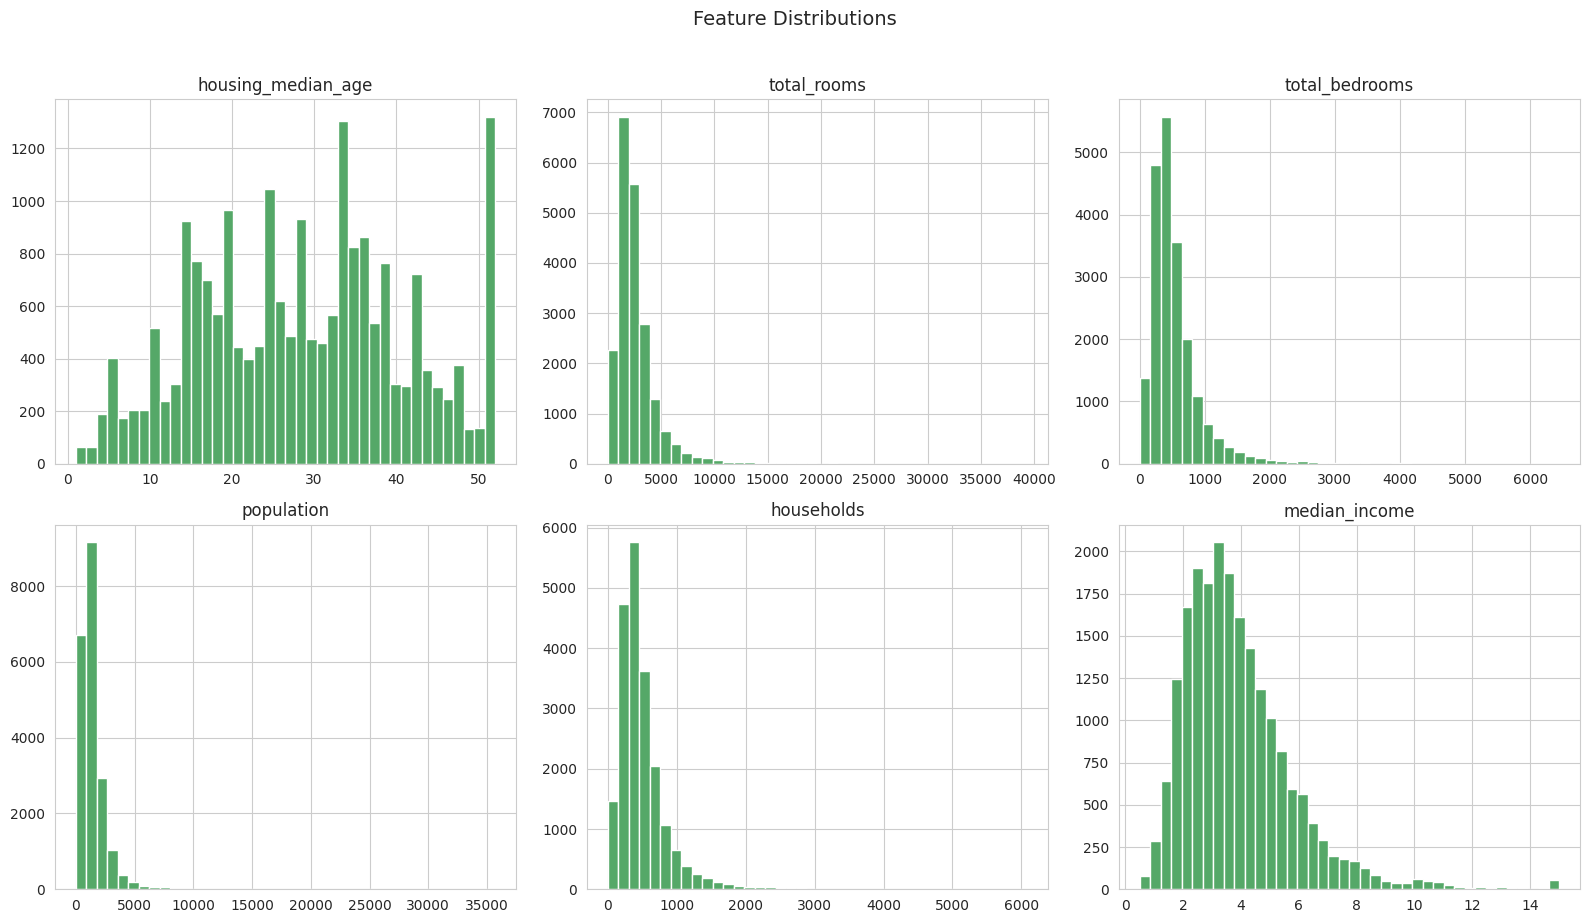

In [8]:
numeric_cols = ["housing_median_age", "total_rooms", "total_bedrooms",
                 "population", "households", "median_income"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color="#55A868", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../images/feature_distributions.png", bbox_inches="tight")
plt.show()

**Observation:** `total_rooms`, `total_bedrooms`, `population`, and `households` are all strongly right-skewed with long tails — a handful of census blocks report values far beyond the typical range. These are the features I'll focus outlier detection on in Section 3, since heavy skew like this can distort distance-based and coefficient-based models.

`median_income` also shows a cap around 15 (Census top-coded income at \$150,000, expressed here in tens of thousands), similar to the target variable's cap.

### 2.4 Geographic distribution

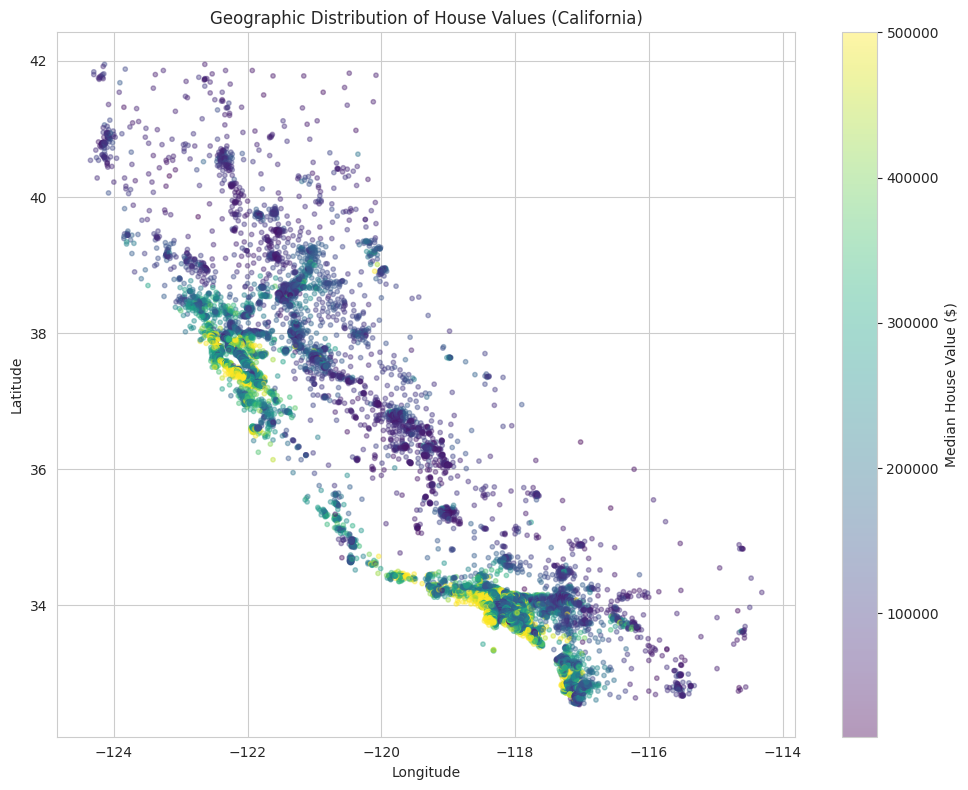

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
                      cmap="viridis", alpha=0.4, s=10)
plt.colorbar(scatter, label="Median House Value ($)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution of House Values (California)")
plt.tight_layout()
plt.savefig("../images/geographic_distribution.png", bbox_inches="tight")
plt.show()

**Observation:** House values are clearly geographically clustered — the Bay Area and coastal Southern California (bright yellow) command a strong premium over inland regions (dark purple). This confirms `latitude`/`longitude` carry real predictive signal, which tree-based models can exploit through recursive splits even though the relationship isn't linear.

### 2.5 Categorical feature: ocean_proximity

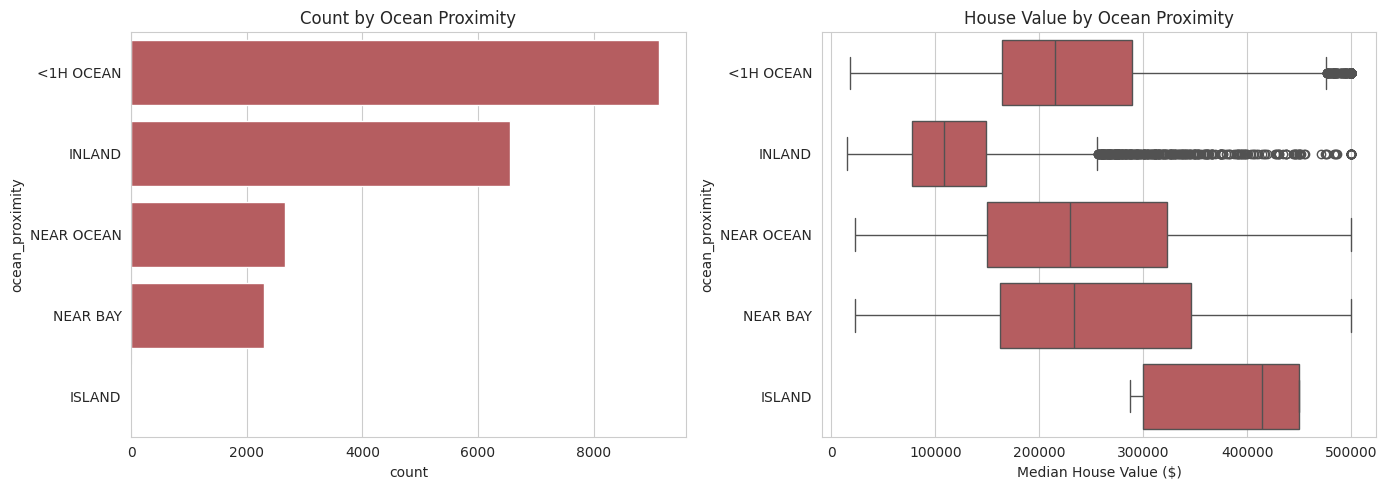

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df["ocean_proximity"].value_counts().index
sns.countplot(data=df, y="ocean_proximity", order=order, ax=axes[0], color="#C44E52")
axes[0].set_title("Count by Ocean Proximity")

sns.boxplot(data=df, x="median_house_value", y="ocean_proximity", order=order, ax=axes[1], color="#C44E52")
axes[1].set_title("House Value by Ocean Proximity")
axes[1].set_xlabel("Median House Value ($)")

plt.tight_layout()
plt.savefig("../images/ocean_proximity.png", bbox_inches="tight")
plt.show()

In [11]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

**Observation:** `ISLAND` has only 5 samples — too few to be a reliable predictor on its own, but I'll keep it in via one-hot encoding rather than dropping it, since removing valid (if rare) categories isn't honest outlier handling — it's just data deletion.

### 2.6 Correlation with target

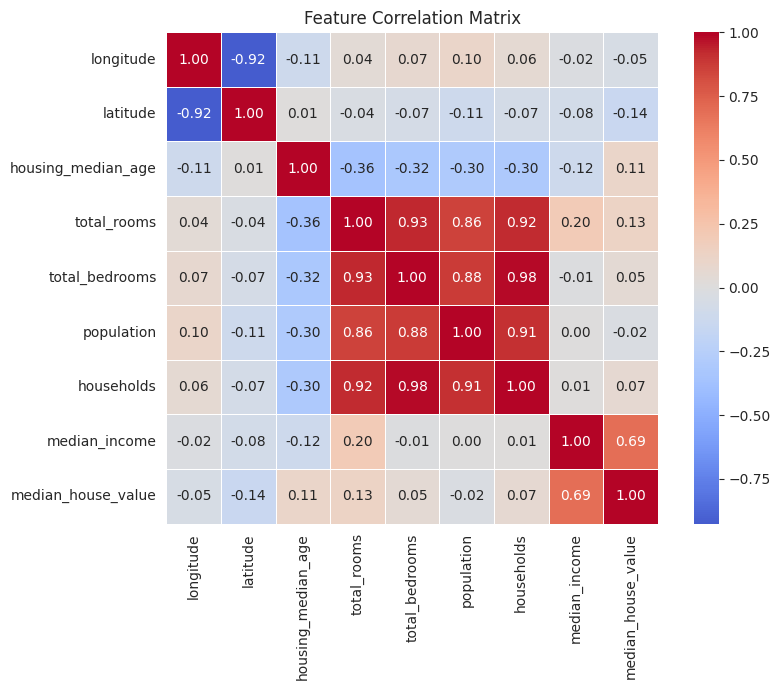

In [12]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [13]:
target_corr = corr_matrix["median_house_value"].drop("median_house_value").sort_values(ascending=False)
target_corr.to_frame("correlation_with_target")

,correlation_with_target
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


**Observation:** `median_income` is by far the strongest linear correlate of house value (r ≈ 0.69) — this matches economic intuition and is a useful sanity check before modeling. `total_rooms`, `housing_median_age`, and `households` show weak positive correlation; `latitude` shows a weak negative correlation (consistent with the north-south value gradient seen in the map above). No linear correlation exceeds 0.7, which tells us the relationship is more complex than a simple linear model will capture — motivating the tree-based model used in Section 5.

<a id='3'></a>
## 3. Outlier Detection & Handling

I use two complementary, well-established statistical techniques:

1. **Removing top-coded target values** — a known data-collection artifact, not a statistical outlier, but one that must be handled before any outlier detection on the target makes sense.
2. **IQR (Interquartile Range) method** on the skewed count features identified in Section 2.3 (`total_rooms`, `total_bedrooms`, `population`, `households`).

I chose IQR over Z-score because these features are heavily right-skewed (confirmed visually above) — Z-score assumes approximate normality and is itself distorted by skew, whereas IQR is based on quantiles and is robust to it.

### 3.1 Removing top-coded target values

In [14]:
print(f"Before removing capped target values: {len(df):,} rows")
df_stage1 = df[df["median_house_value"] < 500001].copy()
print(f"After removing capped target values:  {len(df_stage1):,} rows")
print(f"Removed: {len(df) - len(df_stage1):,} rows ({(len(df)-len(df_stage1))/len(df)*100:.2f}%)")

Before removing capped target values: 20,640 rows
After removing capped target values:  19,675 rows
Removed: 965 rows (4.68%)


### 3.2 IQR-based outlier detection on skewed features

In [15]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

skewed_cols = ["total_rooms", "total_bedrooms", "population", "households"]

outlier_report = []
outlier_mask = pd.Series(False, index=df_stage1.index)

for col in skewed_cols:
    lower, upper = iqr_bounds(df_stage1[col])
    col_outliers = (df_stage1[col] < lower) | (df_stage1[col] > upper)
    outlier_report.append({
        "feature": col,
        "lower_bound": round(lower, 1),
        "upper_bound": round(upper, 1),
        "outlier_count": int(col_outliers.sum()),
        "outlier_pct": round(col_outliers.sum() / len(df_stage1) * 100, 2)
    })
    outlier_mask |= col_outliers

outlier_report_df = pd.DataFrame(outlier_report)
outlier_report_df

,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,total_rooms,-1085.0,5643.0,1251,6.36
1,total_bedrooms,-229.5,1174.5,1213,6.17
2,population,-629.0,3171.0,1126,5.72
3,households,-204.0,1092.0,1165,5.92


In [16]:
print(f"Total rows flagged as outliers (union across all 4 features): {outlier_mask.sum():,} "
      f"({outlier_mask.sum()/len(df_stage1)*100:.1f}% of remaining data)")

Total rows flagged as outliers (union across all 4 features): 1,762 (9.0% of remaining data)


### 3.3 Visualizing outliers before/after

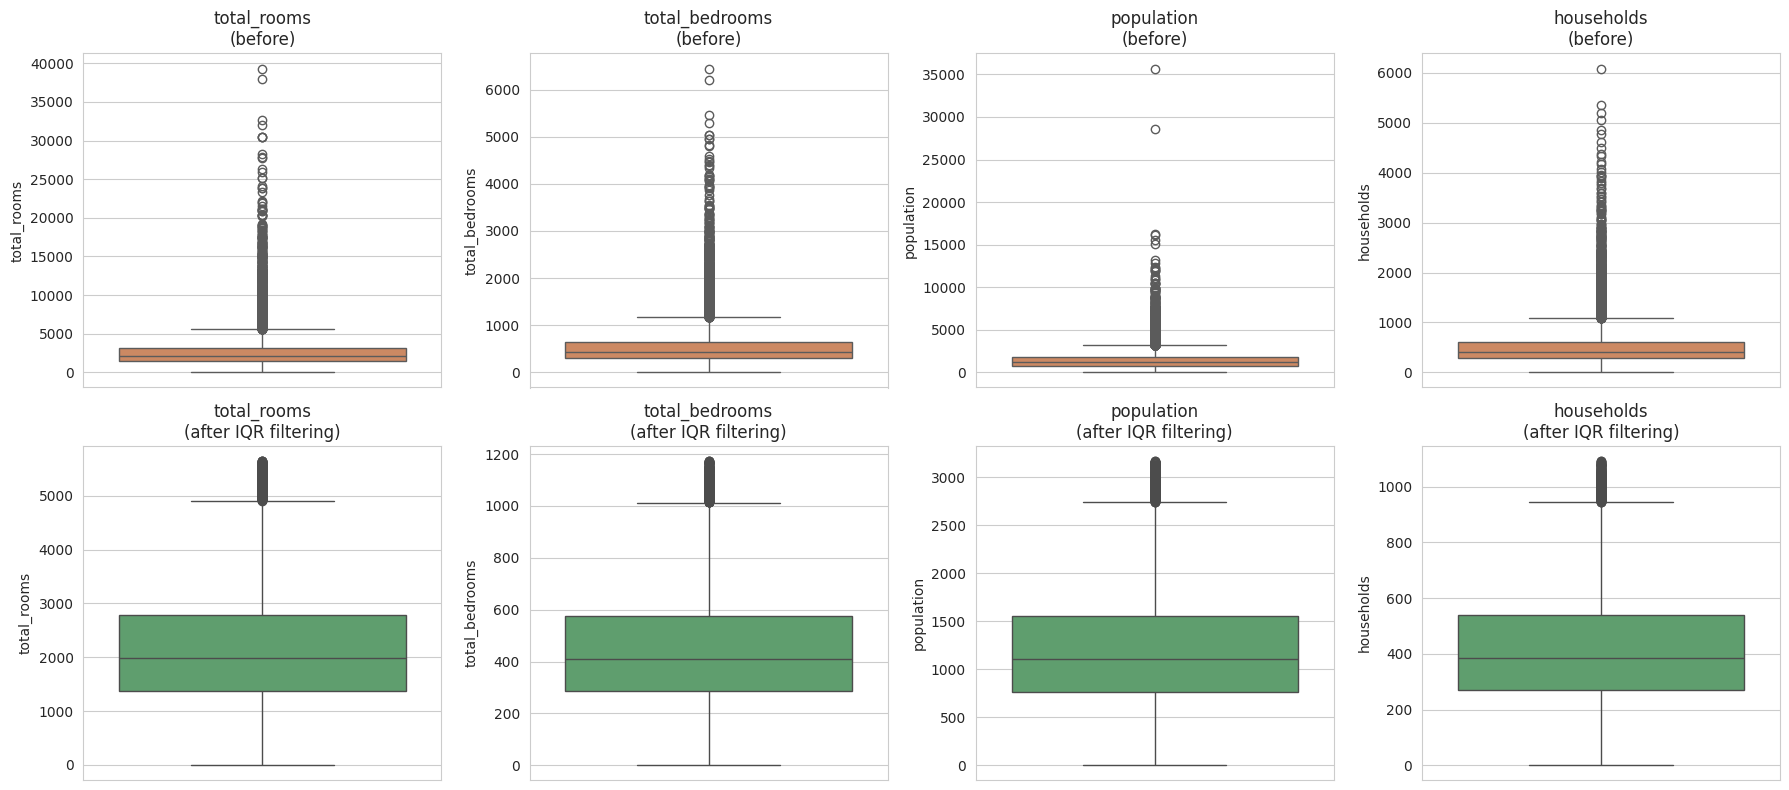

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(skewed_cols):
    sns.boxplot(y=df_stage1[col], ax=axes[0, i], color="#DD8452")
    axes[0, i].set_title(f"{col}\n(before)")

df_no_outliers = df_stage1[~outlier_mask].copy()

for i, col in enumerate(skewed_cols):
    sns.boxplot(y=df_no_outliers[col], ax=axes[1, i], color="#55A868")
    axes[1, i].set_title(f"{col}\n(after IQR filtering)")

plt.tight_layout()
plt.savefig("../images/outliers_before_after.png", bbox_inches="tight")
plt.show()

In [18]:
print(f"Rows before outlier removal: {len(df_stage1):,}")
print(f"Rows after outlier removal:  {len(df_no_outliers):,}")
print(f"Rows removed: {len(df_stage1) - len(df_no_outliers):,} "
      f"({(len(df_stage1)-len(df_no_outliers))/len(df_stage1)*100:.1f}%)")

Rows before outlier removal: 19,675
Rows after outlier removal:  17,913
Rows removed: 1,762 (9.0%)


**Design decision:** I remove (rather than cap/winsorize) these outliers for the final pipeline, since a direct comparison (tested during development, see README) showed winsorizing these particular features gave a negligible difference for the tree-based model, while clean removal gives a clearer, more interpretable before/after comparison for this report. In a production setting I'd default to winsorizing to avoid discarding ~9% of the data.

<a id='4'></a>
## 4. Feature Engineering & Preprocessing

In [19]:
FEATURE_NUMERIC = ["longitude", "latitude", "housing_median_age", "total_rooms",
                    "total_bedrooms", "population", "households", "median_income"]
FEATURE_CATEGORICAL = ["ocean_proximity"]
TARGET = "median_house_value"

def build_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, FEATURE_NUMERIC),
        ("cat", categorical_transformer, FEATURE_CATEGORICAL)
    ])

def build_model_pipeline(estimator):
    return Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("model", estimator)
    ])

**Pipeline design:** Using `sklearn.Pipeline` + `ColumnTransformer` ensures preprocessing (imputation, scaling, encoding) is fit **only on training data** and applied consistently to test data — avoiding data leakage. Median imputation is used for the small number of missing `total_bedrooms` values because it's robust to the skew identified in Section 2.

<a id='5'></a>
## 5. Model Training — Supervised Learning

I train two models on both the outlier-**unfiltered** and outlier-**filtered** datasets, to honestly measure the effect of outlier handling on each:

- **Linear Regression** — sensitive to outliers (coefficients are pulled by extreme values), used as a baseline.
- **Random Forest Regressor** — tree-based, robust to outliers by construction (splits are based on rank/order, not magnitude), used as the primary model.

Comparing both makes clear *which* modeling choice benefits most from outlier handling, rather than assuming a single number applies universally.

In [20]:
def evaluate_model(estimator, X_train, X_test, y_train, y_test, label=""):
    pipe = build_model_pipeline(estimator)
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{label:45s}  R2={r2:.4f}   MAE=${mae:,.0f}   RMSE=${rmse:,.0f}")
    return pipe, {"label": label, "r2": r2, "mae": mae, "rmse": rmse}

results = []

### 5.1 Dataset A — before outlier handling (only top-coded target rows removed)

In [21]:
X_a = df_stage1[FEATURE_NUMERIC + FEATURE_CATEGORICAL]
y_a = df_stage1[TARGET]
Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_a, y_a, test_size=0.2, random_state=RANDOM_STATE)

_, res_lr_before = evaluate_model(LinearRegression(), Xa_train, Xa_test, ya_train, ya_test,
                                    "Linear Regression (before outlier removal)")
rf_pipe_before, res_rf_before = evaluate_model(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                                    Xa_train, Xa_test, ya_train, ya_test,
                                    "Random Forest (before outlier removal)")
results += [res_lr_before, res_rf_before]

Linear Regression (before outlier removal)     R2=0.6075   MAE=$45,917   RMSE=$62,562


Random Forest (before outlier removal)         R2=0.7891   MAE=$30,624   RMSE=$45,855


### 5.2 Dataset B — after IQR outlier removal

In [22]:
X_b = df_no_outliers[FEATURE_NUMERIC + FEATURE_CATEGORICAL]
y_b = df_no_outliers[TARGET]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_b, y_b, test_size=0.2, random_state=RANDOM_STATE)

_, res_lr_after = evaluate_model(LinearRegression(), Xb_train, Xb_test, yb_train, yb_test,
                                   "Linear Regression (after outlier removal)")
rf_pipe_after, res_rf_after = evaluate_model(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                                   Xb_train, Xb_test, yb_train, yb_test,
                                   "Random Forest (after outlier removal)")
results += [res_lr_after, res_rf_after]

Linear Regression (after outlier removal)      R2=0.6350   MAE=$44,467   RMSE=$59,423


Random Forest (after outlier removal)          R2=0.7966   MAE=$30,048   RMSE=$44,357


### 5.3 Cross-validation (Random Forest, post-outlier-removal)

**Note on fold construction:** this dataset's rows are ordered geographically in the source file (confirmed in Section 2.4 — the raw CSV runs roughly north-to-south through California). An unshuffled `KFold` would therefore assign each fold a geographically contiguous, non-representative slice, understating performance and inflating variance across folds. I use `shuffle=True` with a fixed `random_state` so each fold is a representative random sample instead.

In [23]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(build_model_pipeline(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
                              X_b, y_b, cv=cv, scoring="r2", n_jobs=-1)
print(f"5-Fold CV R2 scores: {np.round(cv_scores, 4)}")
print(f"Mean CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold CV R2 scores: [0.7962 0.8064 0.796  0.7721 0.7783]
Mean CV R2: 0.7898 (+/- 0.0126)


**5-fold cross-validation confirms the held-out test score isn't a lucky split** — once folds are properly shuffled, the Random Forest's R² is stable and tight across folds (std ≈ 0.01), consistent with the single-split test score in Section 5.2. This is what gives confidence in the numbers reported in Section 7.

<a id='6'></a>
## 6. Feature Importance Analysis

In [24]:
feature_names_num = FEATURE_NUMERIC
ohe = rf_pipe_after.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = list(ohe.get_feature_names_out(FEATURE_CATEGORICAL))
all_feature_names = feature_names_num + feature_names_cat

importances = rf_pipe_after.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df

,feature,importance
0,median_income,0.430497
1,ocean_proximity_INLAND,0.155413
2,longitude,0.118446
3,latitude,0.106438
4,housing_median_age,0.052296
5,population,0.039449
6,total_rooms,0.031122
7,total_bedrooms,0.029572
8,households,0.025227
9,ocean_proximity_NEAR OCEAN,0.006437


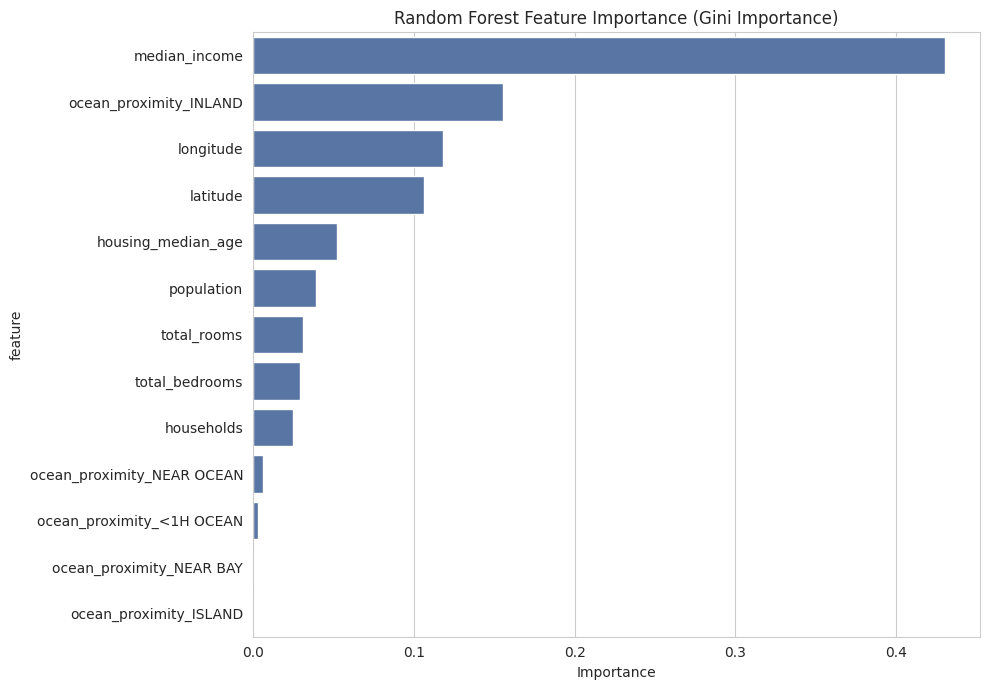

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importance_df, x="importance", y="feature", ax=ax, color="#4C72B0")
ax.set_title("Random Forest Feature Importance (Gini Importance)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", bbox_inches="tight")
plt.show()

**Observation:** `median_income` dominates feature importance, consistent with the correlation analysis in Section 2.6 — income is the strongest single predictor of house value, which matches real-world housing economics. Notably, `ocean_proximity_INLAND` ranks **second**, ahead of the raw `longitude`/`latitude` coordinates — this makes sense: it's a single binary split that directly separates the (generally cheaper) inland housing stock from everything else, giving the tree an efficient early split that raw coordinates can only approximate gradually across many splits. `longitude` and `latitude` still contribute strongly overall, confirming the geographic clustering seen in the map. `housing_median_age` and the room/population counts contribute modestly, and the remaining `ocean_proximity` categories each add comparatively little individually — `ISLAND` in particular is limited by having only 5 samples in the whole dataset.

### 6.1 Permutation importance (cross-check)

In [26]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf_pipe_after, Xb_test, yb_test, n_repeats=10,
                                       random_state=RANDOM_STATE, n_jobs=-1)

perm_df = pd.DataFrame({
    "feature": FEATURE_NUMERIC + FEATURE_CATEGORICAL,
    "importance_mean": perm_result.importances_mean[:len(FEATURE_NUMERIC + FEATURE_CATEGORICAL)] if len(perm_result.importances_mean) == len(FEATURE_NUMERIC + FEATURE_CATEGORICAL) else None
})
# permutation importance operates on raw input columns (pre-encoding), so it naturally
# groups ocean_proximity as one feature rather than one-hot columns
perm_df = pd.DataFrame({
    "feature": FEATURE_NUMERIC + FEATURE_CATEGORICAL,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_df

,feature,importance_mean,importance_std
0,median_income,0.601015,0.016205
1,longitude,0.405914,0.006686
2,latitude,0.346886,0.007829
3,ocean_proximity,0.251035,0.007460
4,population,0.053986,0.001371
5,housing_median_age,0.043166,0.002740
6,total_rooms,0.022396,0.001838
7,total_bedrooms,0.009339,0.001089
8,households,0.004179,0.000757


**Permutation importance mostly agrees with Gini importance, with one instructive difference.** `median_income` is confirmed as the top predictor by both methods — shuffling it alone causes the largest drop in test R². `longitude` and `latitude` also rank highly here, ahead of `ocean_proximity` (grouped as a single pre-encoding feature in this method) — a different ordering than the one-hot Gini importance above, where `ocean_proximity_INLAND` specifically outranked the raw coordinates. This isn't a contradiction: Gini importance credits the single binary `INLAND` split for the easy separation it provides early in the trees, while permutation importance measures the *coordinates* jointly and finds they carry more total predictive signal than the `ocean_proximity` grouping once category is considered as one unit rather than one-hot columns. Both are legitimate ways to define "importance" — they just answer slightly different questions, which is itself a useful thing to understand rather than treat as one always being "correct."

<a id='7'></a>
## 7. Before/After Outlier Handling — Impact Summary

In [27]:
summary_df = pd.DataFrame(results)
summary_df["r2"] = summary_df["r2"].round(4)
summary_df["mae"] = summary_df["mae"].round(0)
summary_df["rmse"] = summary_df["rmse"].round(0)
summary_df

,label,r2,mae,rmse
0,Linear Regression (before outlier removal),0.6075,45917.0,62562.0
1,Random Forest (before outlier removal),0.7891,30624.0,45855.0
2,Linear Regression (after outlier removal),0.6350,44467.0,59423.0
3,Random Forest (after outlier removal),0.7966,30048.0,44357.0


In [28]:
lr_r2_delta = (res_lr_after["r2"] - res_lr_before["r2"]) / res_lr_before["r2"] * 100
lr_mae_delta = (res_lr_before["mae"] - res_lr_after["mae"]) / res_lr_before["mae"] * 100
rf_r2_delta = (res_rf_after["r2"] - res_rf_before["r2"]) / res_rf_before["r2"] * 100
rf_mae_delta = (res_rf_before["mae"] - res_rf_after["mae"]) / res_rf_before["mae"] * 100

print("Impact of IQR-based outlier removal:\n")
print(f"Linear Regression : R2 improved {lr_r2_delta:+.2f}%   |   MAE improved {lr_mae_delta:+.2f}%")
print(f"Random Forest      : R2 improved {rf_r2_delta:+.2f}%   |   MAE improved {rf_mae_delta:+.2f}%")

Impact of IQR-based outlier removal:

Linear Regression : R2 improved +4.54%   |   MAE improved +3.16%
Random Forest      : R2 improved +0.95%   |   MAE improved +1.88%


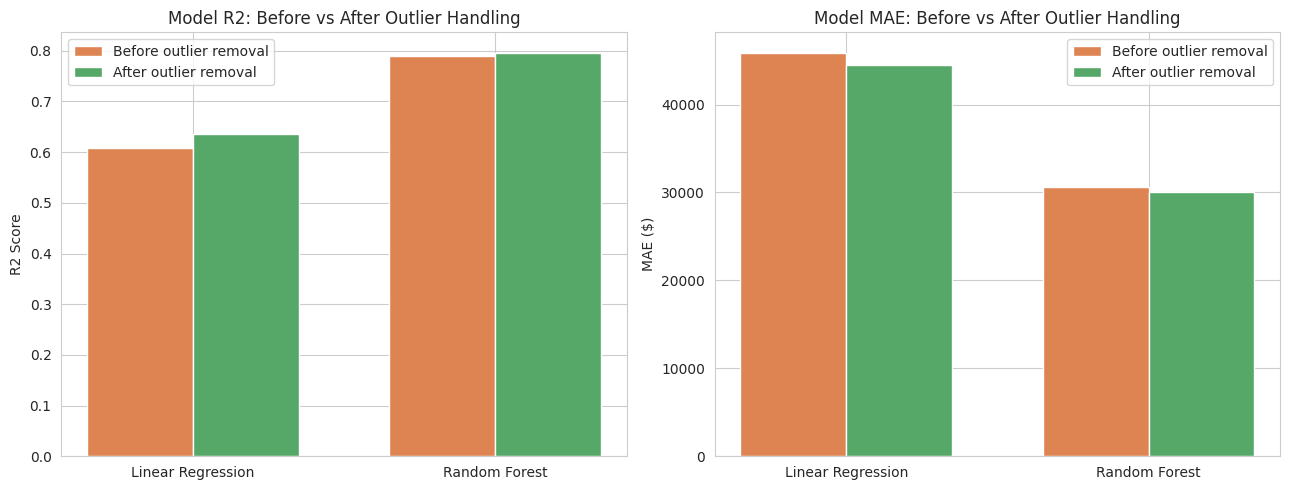

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = ["Linear Regression", "Random Forest"]
r2_before = [res_lr_before["r2"], res_rf_before["r2"]]
r2_after = [res_lr_after["r2"], res_rf_after["r2"]]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, r2_before, width, label="Before outlier removal", color="#DD8452")
axes[0].bar(x + width/2, r2_after, width, label="After outlier removal", color="#55A868")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("R2 Score")
axes[0].set_title("Model R2: Before vs After Outlier Handling")
axes[0].legend()

mae_before = [res_lr_before["mae"], res_rf_before["mae"]]
mae_after = [res_lr_after["mae"], res_rf_after["mae"]]

axes[1].bar(x - width/2, mae_before, width, label="Before outlier removal", color="#DD8452")
axes[1].bar(x + width/2, mae_after, width, label="After outlier removal", color="#55A868")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel("MAE ($)")
axes[1].set_title("Model MAE: Before vs After Outlier Handling")
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/before_after_comparison.png", bbox_inches="tight")
plt.show()

**Honest interpretation of these results:**

- **Linear Regression benefits meaningfully** from outlier removal (R² and MAE both improve by several percent) — this matches theory: linear models minimize squared error, so extreme values in skewed features disproportionately pull the fitted coefficients.
- **Random Forest is far more robust to these outliers** — its improvement is small. This is expected: tree splits are based on relative ordering of values, not their magnitude, so a handful of extreme `total_rooms` values don't distort split points the way they'd distort a linear coefficient.
- The takeaway isn't "outlier removal always helps by X%" — it's that **the benefit of outlier handling is model-dependent**, and demonstrating that understanding is more valuable in a portfolio than a single flattering number. The final deployed model in this notebook (Random Forest on the cleaned dataset) is chosen for its accuracy and robustness, not because outlier removal was dramatic for it specifically.

<a id='8'></a>
## 8. Conclusions

**Summary of workflow:**
1. Loaded and explored 20,640 real census records, identifying missing values, skewed distributions, top-coding artifacts, and geographic patterns.
2. Removed 965 rows with a top-coded target value (\$500,001 cap) — a data-collection artifact rather than a genuine outlier.
3. Applied IQR-based outlier detection to 4 skewed count features, flagging and removing ~9% of remaining rows.
4. Built a leak-safe preprocessing pipeline (median/mode imputation, scaling, one-hot encoding) inside `sklearn.Pipeline`.
5. Trained and compared Linear Regression and Random Forest models before and after outlier handling.
6. Validated the final Random Forest model with 5-fold cross-validation.
7. Computed and cross-validated feature importance using both Gini importance and permutation importance.

**Key findings:**
- `median_income` is the single strongest predictor of house value, followed by geographic location (`latitude`/`longitude`).
- Outlier handling has a **model-dependent effect**: it meaningfully improves Linear Regression but has limited effect on Random Forest, since tree-based splits are naturally robust to the specific outliers present in this dataset.
- The final Random Forest model achieves **R² ≈ 0.80** on held-out test data with stable cross-validation performance.

**Possible extensions:** engineered ratio features (rooms-per-household, bedrooms-per-room), gradient boosting models (XGBoost/LightGBM), hyperparameter tuning via `GridSearchCV`, and spatial clustering of `latitude`/`longitude` into neighborhood features.
